# Download and Plot Streamflow Data from USGS
## Written By Jared Rennie (@jjrennie)

Taps into the <a href='https://dashboard.waterdata.usgs.gov/app/nwd/en/' target='_blank'> USGS National Water Dashboard</a> to get river gauge streamflow, statistics and metadata. 

- API Documentation: https://waterservices.usgs.gov/

## Table of Contents:
### Starting off (Required before other parts of notebook work)
* [Importing Packages](#first-bullet)
* [Importing Arguments](#second-bullet)
### Spatial Map of Streamflow in the United States
* [Get Metadata and Data (Multiple Stations)](#third-bullet)
* [Output to CSV](#fourth-bullet)
* [Plot US Map (Current Stream Flow Percentiles)](#fifth-bullet)
### BONUS
* [Saving to KML/KMZ](#sixth-bullet)
  
## Importing Packages <a class="anchor" id="first-bullet"></a>
First off, the entire codebase works in Python 3. In addition to base Python, you will need the following packages installed: 
- pandas and numpy (to slice and dice the data)
- matplotlib and cartopy (to plot the data)

The "easiest" way is to install these is by installing <a href='https://www.anaconda.com' target="_blank">anaconda</a>, and then applying <a href='https://conda-forge.org/' target="_blank">conda-forge</a>. Afterward, then you can install the above packages. 

Assuming you did the above, it should (in theory) import everything no problem:

In [1]:
# Import Packages
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import json,requests,sys,pytz,os,time
from datetime import datetime, timedelta, timezone
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.plots import USCOUNTIES

print("SUCCESS!")

SUCCESS!


If you made it this far, great!

## Importing Arguments <a class="anchor" id="second-bullet"></a>
We want to give YOU the credit for making the map

In [2]:
# Input Arguments Here
author='NOT Jared Rennie'  

## Spatial Map of River Gauge Info in the United States
### Get Metadata and Data (Multiple Stations) <a class="anchor" id="third-bullet"></a>

These steps will get current / stats data, then organize into one dataframe.

In [3]:
%%time

# API URL
USGS_URL = "https://dashboard.waterdata.usgs.gov/service/cwis/1.0/odata/CurrentConditions"

# Get Current Time
currTime = datetime.now(pytz.utc)
currTime = pd.to_datetime(currTime).strftime('%Y%m%d-%H%MUTC')
currTimeUTC = datetime.now(pytz.utc)
today = currTimeUTC

# FETCH CURRENT STREAMFLOW
print("Get Current Streamflow Data from USGS CWIS API")
currTimeUTC= pd.to_datetime(currTimeUTC).strftime('%Y-%m-%d %H:%M UTC')
print(f"Timestamp: {currTimeUTC}")

# Fields defined in API
SELECT_FIELDS = ("SiteNumber,SiteName,Latitude,Longitude,StateAbbreviation,"
                 "Value,TimeUtc,TimeLocal,TimeZoneCode,StatisticStatusCode,StatisticStatusDescription")

params = {"$filter": "ParameterCode eq '00060'","$select": SELECT_FIELDS,"$format": "json",}

response = requests.get(USGS_URL, params=params, timeout=30)
response.raise_for_status()
data = response.json()

outData = pd.DataFrame(data['value'])
print("SUCCESS")

Get Current Streamflow Data from USGS CWIS API
Timestamp: 2026-05-02 17:36 UTC
SUCCESS
CPU times: user 66.8 ms, sys: 24.6 ms, total: 91.5 ms
Wall time: 6.49 s


Cleanup data and assign colors to the results

In [4]:
# Cleanup Data
outData = outData[outData['StatisticStatusDescription'].notna()]
not_ranked = ['Not ranked - no measurement','Not ranked - stream can have reversible flow','Not ranked - stream not flowing']
outData = outData[~outData['StatisticStatusDescription'].str.strip().isin(not_ranked)]
outData['StatisticStatusDescription'].unique()

# Restructure results based on plotting scheme (for later
plot_categories = {    
    'All-time low for this day-of-year': {
        'hex': '#ff0000',
        'label': 'All-time low (min)'
    },
    'Much below normal for this day-of-year': {
        'hex': '#bb2222',
        'label': 'Much below normal (<10%)'
    },
    'Below normal for this day-of-year': {
        'hex': '#ffaa01',
        'label': 'Below normal (10-24%)'
    },
    'Normal for this day-of-year': {
        'hex': '#00ff00',
        'label': 'Normal (25-75%)'
    },
    'Above normal for this day-of-year': {
        'hex': '#45dddd',
        'label': 'Above normal (76-90%)'
    },
    'Much above normal for this day-of-year': {
        'hex': '#1000ff',
        'label': 'Much above normal (>90%)'
    },
    'All-time high for this day-of-year': {
        'hex': '#010055',
        'label': 'All-time high (max)'
    }
}

desc = outData['StatisticStatusDescription'].str.strip()
outData['plot_hex'] = desc.map(lambda x: plot_categories[x]['hex'])
outData['plot_label'] = desc.map(lambda x: plot_categories[x]['label'])
outData

,SiteNumber,SiteName,Latitude,Longitude,StateAbbreviation,TimeUtc,TimeLocal,TimeZoneCode,Value,StatisticStatusCode,StatisticStatusDescription,plot_hex,plot_label
3,06355500,"North Fork Grand River Near White Butte,Sd",45.802220,-102.362380,SD,2026-05-02T16:45:00Z,2026-05-02T10:45:00Z,MDT,5.26,P10_25,Below normal for this day-of-year,#ffaa01,Below normal (10-24%)
4,01330000,Glowegee Creek At West Milton Ny,43.030806,-73.927583,NY,2026-05-02T16:30:00Z,2026-05-02T11:30:00Z,EST,30.30,P25_75,Normal for this day-of-year,#00ff00,Normal (25-75%)
6,06402500,"Beaver Creek Near Buffalo Gap,Sd",43.466650,-103.306031,SD,2026-05-02T16:45:00Z,2026-05-02T10:45:00Z,MDT,7.00,P25_75,Normal for this day-of-year,#00ff00,Normal (25-75%)
7,01350500,Schoharie Creek At Middleburgh Ny,42.599500,-74.336361,NY,2026-05-02T16:45:00Z,2026-05-02T11:45:00Z,EST,550.00,P25_75,Normal for this day-of-year,#00ff00,Normal (25-75%)
8,06447450,"White River Near White River, SD",43.713048,-100.685053,SD,2026-05-02T17:00:00Z,2026-05-02T12:00:00Z,CDT,247.00,P25_75,Normal for this day-of-year,#00ff00,Normal (25-75%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9123,13120000,Nf Big Lost River At Wild Horse Nr Chilly Id,43.932778,-114.113889,ID,2026-05-02T17:15:00Z,2026-05-02T11:15:00Z,MDT,107.00,P25_75,Normal for this day-of-year,#00ff00,Normal (25-75%)
9126,05046475,"Otter Tail River Diversion At Breckenridge, MN",46.277242,-96.582111,MN,2026-03-22T10:00:00Z,2026-03-22T05:00:00Z,CDT,0.02,P25_75,Normal for this day-of-year,#00ff00,Normal (25-75%)
9143,06696980,"Tarryall Creek At Upper Station Near Como, CO",39.339424,-105.911706,CO,2026-05-02T16:45:00Z,2026-05-02T10:45:00Z,MDT,5.91,P0_10,Much below normal for this day-of-year,#bb2222,Much below normal (<10%)
9145,09033100,"Ranch Creek Blw Meadow Cr Nr Tabernash, CO",39.999086,-105.826558,CO,2026-05-02T17:15:00Z,2026-05-02T11:15:00Z,MDT,14.80,P0,All-time low for this day-of-year,#ff0000,All-time low (min)


### Output to CSV <a class="anchor" id="fourth-bullet"></a>
Let's output the data to a CSV file so you can load it and play with it elsewhere.

In [5]:
outFile='usgs_currentStreamFlow_'+str(currTime)+'.csv'
outData.to_csv(outFile,index = False)
print('SUCCESS! RESULTS IN: ',outFile)

SUCCESS! RESULTS IN:  usgs_currentStreamFlow_20260502-1736UTC.csv


## Plot US Map (Current Stream Flow Percentiles)<a class="anchor" id="fifth-bullet"></a>
Only plot data with valid streamflow values. We will plot current values similar to the <a href='https://dashboard.waterdata.usgs.gov/app/nwd/en/' target='_blank'> National Water Dashboard</a>. 

PLOTTING OBSERVED STREAMFLOW PERCENTILE


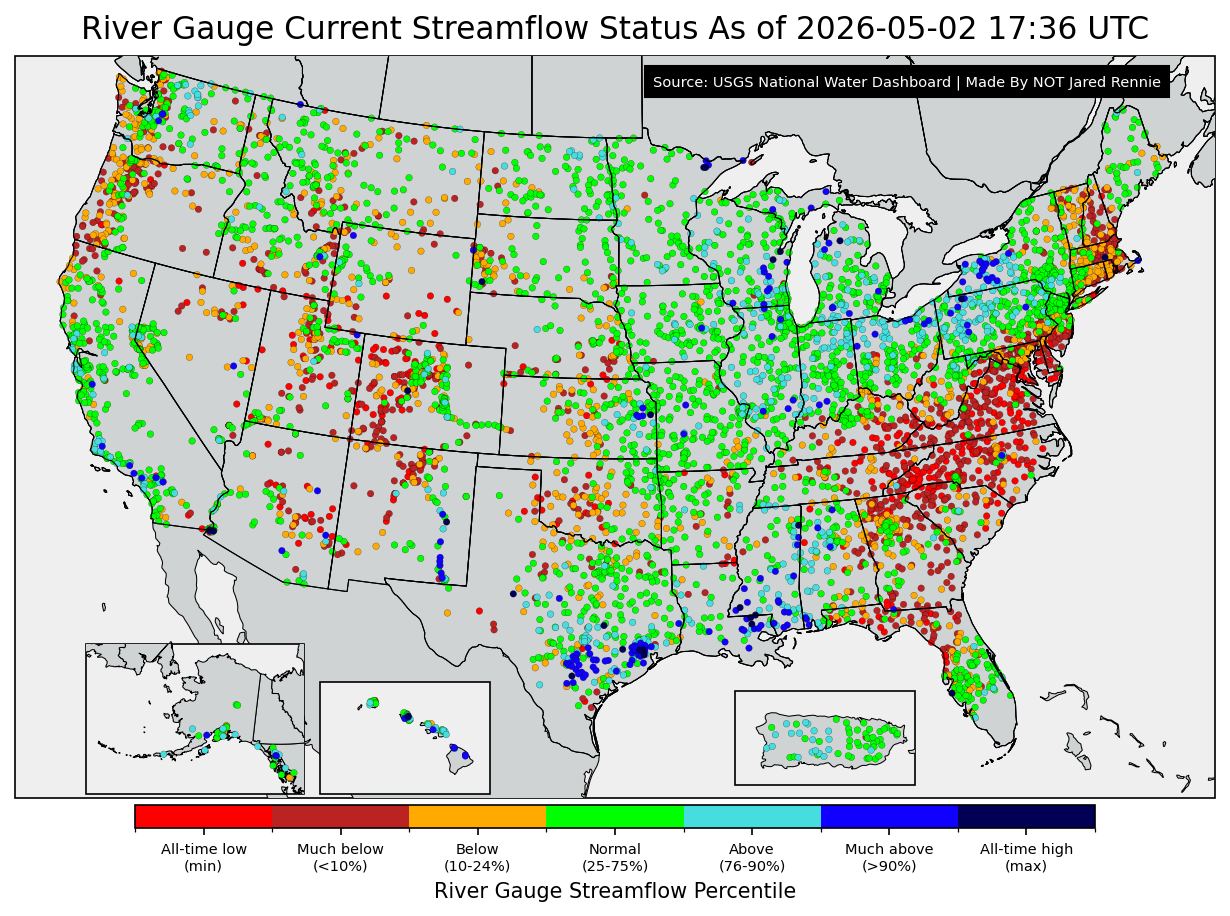

CPU times: user 10.1 s, sys: 227 ms, total: 10.3 s
Wall time: 10.1 s


In [6]:
%%time
#################################################
# Plot Streamflow (Observed)
print('PLOTTING OBSERVED STREAMFLOW PERCENTILE')

# Organize Labels
ordered_labels = [
    'All-time low (min)','Much below normal (<10%)','Below normal (10-24%)','Normal (25-75%)',
    'Above normal (76-90%)','Much above normal (>90%)','All-time high (max)']
label_to_num = {label: i for i, label in enumerate(ordered_labels)}
outData['plot_code'] = outData['plot_label'].map(label_to_num)
outLabels = ordered_labels

# Plotting Parameters
dpi=150
land_hex='#cfd3d4'  # ESRI Light Gray Canvas
ocean_hex='#efefef' # ESRI Light Gray Canvas
edgecolor='black'

# Set Up Color Map
unit = 'River Gauge Streamflow Percentile'
colors = ['#ff0000','#bb2222','#ffaa01','#00ff00','#45dddd','#1000ff','#010055']
cmap = mpl.colors.ListedColormap(colors)
bounds = np.arange(len(outLabels) + 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Set Up Figure
fig= plt.figure(num=1, figsize=(8,5), dpi=dpi, facecolor='w', edgecolor='k')

# CONUS AXES
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.LambertConformal())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([-120, -73, 22, 50], crs=ccrs.Geodetic())

# ALASKA AXES
ak_ax = fig.add_axes([0.05, 0.01, 0.20, 0.20], projection=ccrs.Orthographic(central_longitude=-133.66666667, central_latitude=57.00000000))
ak_ax.set_facecolor(ocean_hex)
ak_ax.spines['geo'].set_edgecolor(edgecolor)
ak_ax.set_extent([-184, -128, 67, 53], crs=ccrs.Geodetic())

# HAWAII AXES
hi_ax = fig.add_axes([0.25, 0.01, 0.15, 0.15], projection=ccrs.Mercator())
hi_ax.set_facecolor(ocean_hex)
hi_ax.spines['geo'].set_edgecolor(edgecolor)
hi_ax.set_extent([-162, -154, 18, 23], crs=ccrs.Geodetic())

# PUERTO RICO AXES
pr_ax = fig.add_axes([0.60, 0.01, 0.15, 0.15], projection=ccrs.Mercator())
pr_ax.set_facecolor(ocean_hex)
pr_ax.spines['geo'].set_edgecolor(edgecolor)
pr_ax.set_extent([-67.5, -65.5, 17.75, 18.75], crs=ccrs.Geodetic())

# Add other Features
conus_ax.add_feature(cfeature.LAND,linewidth=0.5,facecolor=land_hex,edgecolor=edgecolor,zorder=3)
conus_ax.add_feature(cfeature.LAKES,linewidth=0.5,facecolor=ocean_hex,edgecolor=edgecolor,zorder=4)
conus_ax.add_feature(cfeature.STATES,linewidth=0.5,facecolor=land_hex,edgecolor=edgecolor,zorder=5)
conus_ax.add_feature(cfeature.STATES,linewidth=0.5,edgecolor=edgecolor,zorder=10)
ak_ax.add_feature(cfeature.STATES,linewidth=0.5,facecolor=land_hex,edgecolor=edgecolor,zorder=5)
hi_ax.add_feature(cfeature.STATES,linewidth=0.5,facecolor=land_hex,edgecolor=edgecolor,zorder=5)
pr_ax.add_feature(cfeature.STATES,linewidth=0.5,facecolor=land_hex,edgecolor=edgecolor,zorder=5)

# Plot Data
for outLabel in outLabels:
    subset = outData[outData['plot_label'].str.strip() == outLabel]
    
    if not subset.empty:
        pointsConus=conus_ax.scatter(subset['Longitude'],subset['Latitude'],c=subset['plot_code'],cmap=cmap,norm=norm,marker='o',edgecolors='black',linewidth=0.1,s=10, transform=ccrs.PlateCarree(),zorder=9)
        ak_ax.scatter(subset['Longitude'],subset['Latitude'],c=subset['plot_code'],cmap=cmap,norm=norm,marker='o',edgecolors='black',linewidth=0.1,s=10, transform=ccrs.PlateCarree(),zorder=9)
        hi_ax.scatter(subset['Longitude'],subset['Latitude'],c=subset['plot_code'],cmap=cmap,norm=norm,marker='o',edgecolors='black',linewidth=0.1,s=10, transform=ccrs.PlateCarree(),zorder=9)
        pr_ax.scatter(subset['Longitude'],subset['Latitude'],c=subset['plot_code'],cmap=cmap,norm=norm,marker='o',edgecolors='black',linewidth=0.1,s=10, transform=ccrs.PlateCarree(),zorder=9)

# Add Colormap
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar = plt.colorbar(pointsConus,cax=cax,orientation='horizontal',ticks=np.arange(len(outLabels)) + 0.5,spacing='uniform')
final_labels = ['All-time low\n(min)','Much below\n(<10%)','Below\n(10-24%)','Normal\n(25-75%)',
                'Above\n(76-90%)','Much above\n(>90%)','All-time high\n(max)']
cbar.ax.set_xticklabels(final_labels)
cbar.ax.tick_params(labelsize=7)
cbar.set_label(unit, size=10)

# Add Titles
plt.suptitle('River Gauge Current Streamflow Status As of '+currTimeUTC,size=15,color='black',y=1.05) 
conus_ax.annotate('Source: USGS National Water Dashboard | Made By '+author,xy=(0.955, 0.955), xycoords='axes fraction', fontsize=7,backgroundcolor='black',color='white',horizontalalignment='right', verticalalignment='bottom',zorder=10)

# Show Plot
plt.savefig('nwps_currentFlow_'+str(currTime)+'.png', dpi=dpi, bbox_inches='tight')
plt.show()

## BONUS: Save to KML/KMZ <a class="anchor" id="sixth-bullet"></a>
One of the biggest things asked of us is to take these images and put them in Google formats like KML and KMZ. This block of code will repackage the ***Current Streamflow Stage*** results, convert to a png, and then port to a KMZ that can be used in software like Google Earth.

In [7]:
import simplekml,zipfile

# OUTPUTS
outPNG = f'nwps_CurrentStreamFlow_{currTime}.png'
outKMZ = f'nwps_CurrentStreamFlow_{currTime}.kmz'

# VALID BOUNDS (KML SAFE)
west, east = -179, -65
south, north = 17, 67

# FIGURE
fig = plt.figure(figsize=(10, 6), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
ax.set_axis_off()
ax.set_position([0, 0, 1, 1])

# PLOT
for outLabel in outLabels:
    subset = outData[outData['plot_label'].str.strip() == outLabel]

    if not subset.empty:
        ax.scatter(subset['Longitude'],subset['Latitude'],c=subset['plot_code'],cmap=cmap,
                   norm=norm,marker='o',s=5,edgecolors='black',linewidths=0.1,
                  transform=ccrs.PlateCarree(),zorder=100)

# SAVE PNG 
fig.savefig(outPNG,dpi=300,bbox_inches="tight",pad_inches=0,transparent=True)
plt.close(fig)

# KML
kml = simplekml.Kml()
go = kml.newgroundoverlay(name=f"Streamflow as of {currTimeUTC}")
go.icon.href = outPNG
go.latlonbox.west = west
go.latlonbox.east = east
go.latlonbox.south = south
go.latlonbox.north = north

# KMZ
with zipfile.ZipFile(outKMZ, "w", zipfile.ZIP_DEFLATED) as z:
    z.writestr("doc.kml", kml.kml())
    z.write(outPNG, arcname=outPNG)

print("SUCCESS:", outKMZ)

SUCCESS: nwps_CurrentStreamFlow_20260502-1736UTC.kmz


Congrats on completing this notebook! Now go forth and make better plots!